In [19]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import M_sun, G, c
from scipy.constants import pi

from mpmath import hyp1f1

from astropy.constants import M_sun

In [60]:
# ringdown signal

def ringdown(T, M_source, h0=1, samples=20000):

    from astropy.constants import M_sun
    from scipy.constants import pi
    from numpy import exp, cos, linspace

    t = linspace(0, T, samples)

    # signal parameters
    M_source = M_source * M_sun.value                   # convert source mass to SI units

    f0 = (1.207 * 10**4) * (M_sun.value / M_source)     # source carrier frequency
    omega0 = 2 * pi * f0

    Gamma = 1.496 * f0                                  # inverse damping time

    h = h0 * exp(-1 * Gamma * t) * cos(omega0 * t)      # strain signal

    return t, h 

In [ ]:
def F_pml(t, h, y, M_lens):

    from astropy.constants import M_sun, G, c
    from scipy.constants import pi
    from mpmath import hyp1f1
    from numpy import exp, conj, any, where, isnan

    # values
    N = len(t)
    Rs = 2 * (M_lens*M_sun.value) * G.value / c.value**2
    tM = 2 * Rs / c.value

    # frequency
    freqs = np.fft.fftfreq(N, d=t[1]-t[0])

    # angular frequency
    omega = 2 * pi * freqs

    # dimensionless frequency
    nu = (tM / (2 * pi)) * omega

    # amplification factor
    F = np.empty(N, dtype=complex)

    # set zero-component 
    F[0] = 1.0 + 0.0j

    # index range parameter
    k_max = N // 2

    # calculate amplification factor
    for k in range(1, k_max + 1):

        w = nu[k]

        if w <= 0:
            F[k] = 1.0 + 0.0j
            continue

        a = 1.0j * pi * w
        b = 1.0
        z = 1.0j * pi * w * y**2

        try:
            hyp = complex(hyp1f1(a,b,z))
        except Exception as exc:
            hyp = 1.0 + 0.0j

        A_num = (2 * pi **2) * w
        A_den = 1 - exp(-2 * (pi**2) * w)

        A = (A_num/A_den)**(1/2)

        F[k] = A * hyp 

    if N % 2 == 0:
        F[k_max] = F[k_max].real + 0.0j
        
    for k in range(1 + k_max + 1):
        F[-k] = conj(F[k]) 

    if any(isnan(F)):
        print("Warning: NaNs present in F; replacing with 1.0 where NaN")
        F = np.where(np.isnan(F), 1.0 + 0j, F)


    return F, nu
                              

In [ ]:
# signal parameters
#t = np.linspace(0,0.04,20000)
#M_lens = 250 * M_sun.value
#h0 = 1.0                                        # maximum amplitude
#nu0 = 5/4                                       # Fresnel number
#y = 0.1                                         # source position
#M_source = 0.24 * M_lens / nu0                                                 
#f0 = 1.207*10**(4)*(M_sun.value/M_source)
#Gamma = 1.496 * f0
#omega0 = 2*pi*f0
#h = h0 * np.exp(-Gamma*t)*np.cos(omega0 * t)

### Effect of lens mass 

Effect of lens mass, for $M_{\text{Lens}} = [1, 10, 100, 300, 500] \ M_{\odot}$

In [149]:
# source
t, h = ringdown(T=0.04, M_source=30) 
N = len(t)

# lens plane parameters
M_lens = np.array([1, 10, 100, 300, 500])           # PML masses
y = 0.1                                             # source position

# unshifted amplification factor 
F_arr = []
nu_arr = []

for lens in M_lens: 
    F, nu = F_pml(t, h, y, lens)
    F_arr.append(F)
    nu_arr.append(nu)

# fourier transform of unlensed signal
h_tilde = np.fft.fft(h)

# amplification factors
F_list = []
nu_list = []

for lens_mass in M_lens:
    F, nu = F_pml(t, h, y, M_lens=lens_mass)
    F_list.append(F)
    nu_list.append(nu)

F_arr = np.array(F_list)
nu_arr = np.array(nu_list)

# lensed signals
hL_tilde_list = []
hL_list = []

for F in F_arr:
    hL_tilde_temp = h_tilde * F
    hL_temp = np.fft.ifft(hL_tilde_temp)

    hL_tilde_list.append(hL_tilde_temp)
    hL_list.append(hL_temp)

hL_tilde_arr = np.array(hL_tilde_list)
hL_arr = np.array(hL_list)

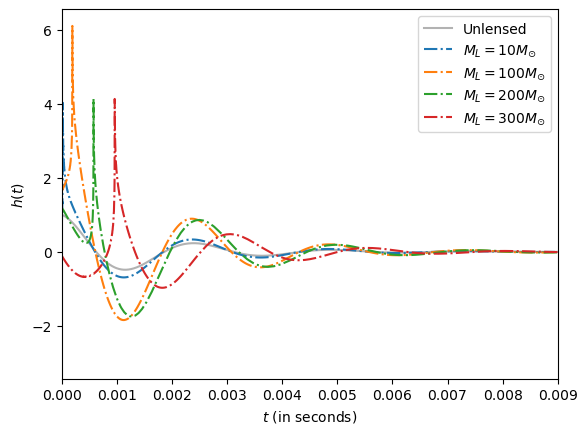

In [150]:
# unlensed vs lensed signals

plt.plot(t, h, alpha=0.3, label="Unlensed", color="black")

#plt.plot(t, hL[0].real, label=r"$M_{L} = M_{\odot}$")
plt.plot(t, hL[1].real, label=r"$M_{L} = 10M_{\odot}$", ls="-.")
plt.plot(t, hL[2].real, label=r"$M_{L} = 100M_{\odot}$", ls="-.")
plt.plot(t, hL[3].real, label=r"$M_{L} = 200M_{\odot}$", ls="-.")
plt.plot(t, hL[4].real, label=r"$M_{L} = 300M_{\odot}$", ls="-.")

plt.xlim([0,0.009])
plt.xlabel(r"$t$ (in seconds)")
plt.ylabel(r"$h(t)$")

plt.legend()
plt.show()

/var/folders/z7/s5rym2f96s37ltj5j14bx20w0000gn/T/ipykernel_17197/3333608692.py:20: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0,20])


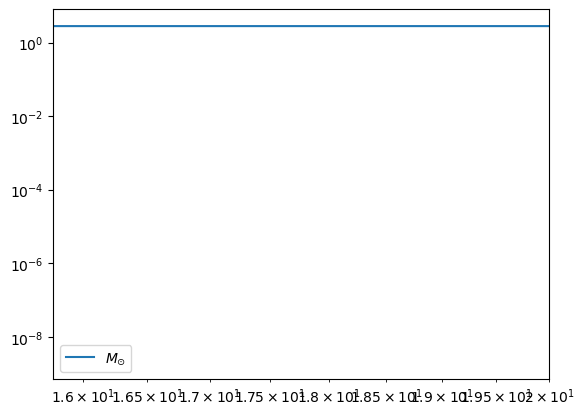

In [ ]:
# strain amplitude in frequency domain

freqs = np.fft.fftfreq(N, d=t[1]-t[0])
omega = 2 * pi * freqs

plt.plot(omega[:N//2], np.abs(hL_arr[0][:N//2]), label=r"$M_{\odot}$")
#plt.plot(freqs[:N//2], np.abs(hL_arr[1][:N//2]), label=r"$10M_{\odot}$")
#plt.plot(freqs[:N//2], np.abs(hL_arr[2][:N//2]), label=r"$100M_{\odot}$")
#plt.plot(freqs[:N//2], np.abs(hL_arr[3][:N//2]), label=r"$300M_{\odot}$")
#plt.plot(freqs[:N//2], np.abs(hL_arr[4][:N//2]), label=r"$500M_{\odot}$")

#plt.plot(nu_arr[0][:N//2], np.abs(hL_arr[0][:N//2]), label=r"$M_{\odot}$")
#plt.plot(nu_arr[1][:N//2], np.abs(hL_arr[1][:N//2]), label=r"$10M_{\odot}$")
#plt.plot(nu_arr[2][:N//2], np.abs(hL_arr[2][:N//2]), label=r"$100M_{\odot}$")
#plt.plot(nu_arr[3][:N//2], np.abs(hL_arr[3][:N//2]), label=r"$300M_{\odot}$")
#plt.plot(nu_arr[4][:N//2], np.abs(hL_arr[4][:N//2]), label=r"$500M_{\odot}$")

plt.yscale("log")
plt.xscale('log')

plt.xlim([0,20])

plt.legend()
plt.show()